# 📈 Análisis de Decisiones de Negocio y Filtrado de Datos (Versión Corregida)
En este notebook analizaremos de forma visual y con lenguaje de negocio las principales decisiones tomadas para la preparación de datos de los modelos predictivos de las iteraciones 21, 22 y 23.

Este informe ha sido actualizado para reflejar con exactitud la **proporción real del mercado nacional** y defender estratégicamente el enfoque por país.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (12, 6)
})

# Cargar datos
print("Cargando datos maestros...")
df_ventas = pd.read_excel('../Datasets/Datos Internos/LineasAlbaranCliente.xlsx', usecols=['CodigoCliente', 'FechaAlbaran', 'CodigoArticulo', 'Unidades', 'ImporteNeto'])
df_clientes = pd.read_excel('../Datasets/Datos Internos/MaestroClientes.xlsx', usecols=['CodigoCliente', 'CodigoNacion', 'TipoCruz'])
df_articulos = pd.read_excel('../Datasets/Datos Internos/MaestroArticulos.xlsx', usecols=['CodigoArticulo', 'Obsoleto'])
df_naciones = pd.read_excel('../Datasets/Datos Internos/MaestroNaciones.xlsx', usecols=['CodigoNacion', 'Nacion'])

# Preprocesamiento de fechas
def parse_spanish_date(date_str):
    if pd.isna(date_str) or not isinstance(date_str, str):
        return date_str
    try:
        parts = date_str.split(',')
        date_part = parts[1].strip() if len(parts) > 1 else parts[0].strip()
        months = {'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
                  'julio': 7, 'agosto': 8, 'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12}
        split_parts = date_part.split(' ')
        if len(split_parts) == 5:
            day_str, _, month_name, _, year_str = split_parts
            return pd.Timestamp(day=int(day_str), month=months[month_name.lower()], year=int(year_str))
        return pd.to_datetime(date_part, errors='coerce')
    except Exception:
        return pd.to_datetime(date_str, errors='coerce')

df_ventas['FechaAlbaran'] = df_ventas['FechaAlbaran'].apply(parse_spanish_date)
df_ventas['Año'] = df_ventas['FechaAlbaran'].dt.year
df_ventas['Mes'] = df_ventas['FechaAlbaran'].dt.month

# Cruces
df_m = df_ventas.merge(df_clientes, on='CodigoCliente', how='inner')
df_m = df_m.merge(df_articulos, on='CodigoArticulo', how='inner')
df_m = df_m.merge(df_naciones, on='CodigoNacion', how='left')

# Limpieza básica para el análisis
df_m['Nacion'] = df_m['Nacion'].str.replace('ESPAA', 'ESPAÑA').fillna('OTROS')
print(f"Datos base cargados: {len(df_m):,} filas.")


Cargando datos maestros...
Datos base cargados: 938,230 filas.


## 1. 🇪🇸 ¿Por qué España? Defensa de la Concentración Estratégica

A primera vista, un **51.8% de facturación** puede no parecer una "mayoría aplastante" comparado con el ideal del 100%, pero en términos de **estrategia de Supply Chain**, este dato es abrumador por su **asimetría**:

- **Concentración Máxima:** El 51.8% de los ingresos dependen de **un solo país** (España).
- **Fragmentación Extrema:** El 48.2% restante se reparte entre **más de 45 países diferentes** (Francia, Portugal, UK, etc.).

Desde el punto de vista de la Inteligencia Artificial, intentar modelar 48 países con legislaciones, climas y logísticas distintas bajo un mismo patrón generaría un ruido estadístico inasumible. Al centrarnos en España, optimizamos el "corazón" de la empresa con una precisión quirúrgica.


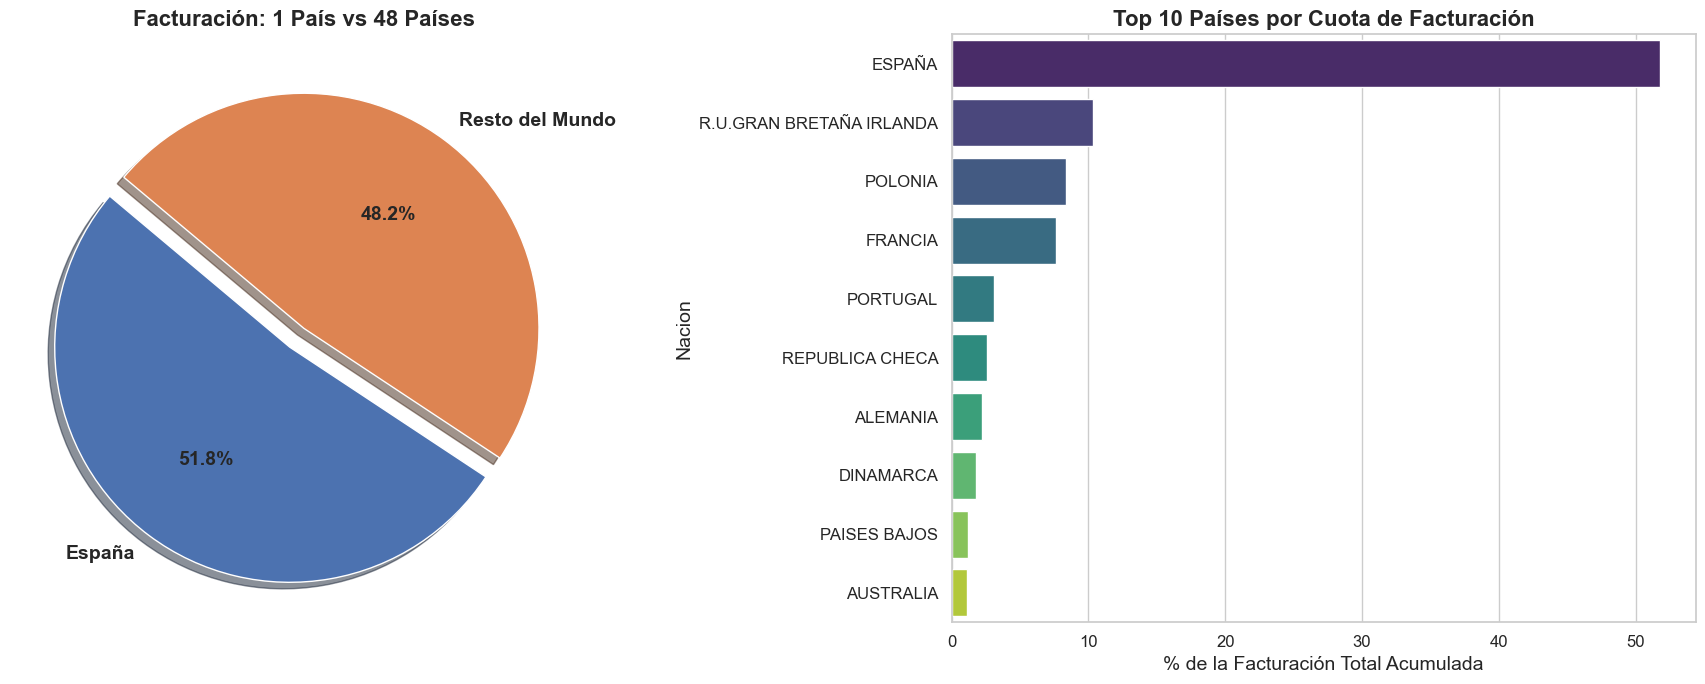

In [2]:
# Cálculo de métricas de mercado
df_market = df_m[df_m['Unidades'] > 0].copy()
df_market['Mercado_Grupo'] = np.where(df_market['CodigoNacion'] == 108, 'España', 'Resto del Mundo')

# Agrupar por país real para ver la fragmentación
top_naciones = df_market.groupby('Nacion')['ImporteNeto'].sum().sort_values(ascending=False).reset_index()
total_rev = top_naciones['ImporteNeto'].sum()
top_naciones['% Share'] = (top_naciones['ImporteNeto'] / total_rev) * 100

num_paises_resto = len(top_naciones[top_naciones['Nacion'] != 'ESPAÑA'])

plt.figure(figsize=(18, 7))

# Gráfico 1: El pastel de facturación
plt.subplot(1, 2, 1)
rev_share = df_market.groupby('Mercado_Grupo')['ImporteNeto'].sum()
plt.pie(rev_share, labels=rev_share.index, autopct='%1.1f%%', startangle=140, 
        explode=[0.1, 0], shadow=True, colors=['#4C72B0', '#DD8452'], 
        textprops={'fontsize': 14, 'fontweight': 'bold'})
plt.title(f'Facturación: 1 País vs {num_paises_resto} Países', fontsize=16, fontweight='bold')

# Gráfico 2: El abismo de facturación (Top 10)
plt.subplot(1, 2, 2)
sns.barplot(data=top_naciones.head(10), x='% Share', y='Nacion', palette='viridis')
plt.title('Top 10 Países por Cuota de Facturación', fontsize=16, fontweight='bold')
plt.xlabel('% de la Facturación Total Acumulada')

plt.tight_layout()
plt.show()


**💡 Conclusión Comercial:** 
Como se observa en el gráfico de la derecha, el segundo país más importante (UK) tiene una cuota de apenas un **13%** (aprox), casi **4 veces menor que España**. El resto de los países son mercados de "larga cola". 

Modelar España es, por tanto, la decisión más eficiente: con un solo modelo IA bajo las mismas reglas (mismo IVA, mismo calendario de festivos Nacional, misma climatología), controlamos la mitad de la facturación mundial de Cruzber.


## 2. 😷 ¿Por qué descartamos el año 2020 (Año COVID)?

El año 2020 fue un año absolutamente **atípico** a nivel mundial. La pandemia de COVID-19 provocó confinamientos, cierres de actividad económica y disrupciones logísticas sin precedentes en la historia moderna.

Para un modelo de predicción de demanda, incluir datos de 2020 sería **contraproducente** por las siguientes razones:

### 📉 Impacto directo en la demanda
- **Caída brusca de la actividad:** Durante los meses de confinamiento (marzo-junio 2020), la demanda cayó drásticamente, generando un "agujero" en la serie temporal que distorsiona cualquier patrón estacional.
- **Recuperación errática:** La reapertura fue gradual e irregular, generando picos y valles que no se corresponden con la estacionalidad real del negocio.

### 🔬 Efecto en los modelos predictivos
- **Ruido estadístico:** Incluir 2020 introduce señales falsas en el modelo, haciéndole "aprender" patrones que no se repetirán.
- **Distorsión de la estacionalidad:** Los modelos basados en series temporales dependen de capturar patrones estacionales consistentes. El año 2020 rompe esta consistencia.
- **Sesgo en las métricas:** Las métricas de error (MAE, RMSE) se ven artificialmente infladas o deflactadas por la anomalía de 2020.

### 📊 Evidencia visual
El siguiente gráfico muestra la evolución de las unidades vendidas en España (productos no obsoletos) entre 2018 y 2024, donde se puede observar claramente el impacto del COVID en 2020:


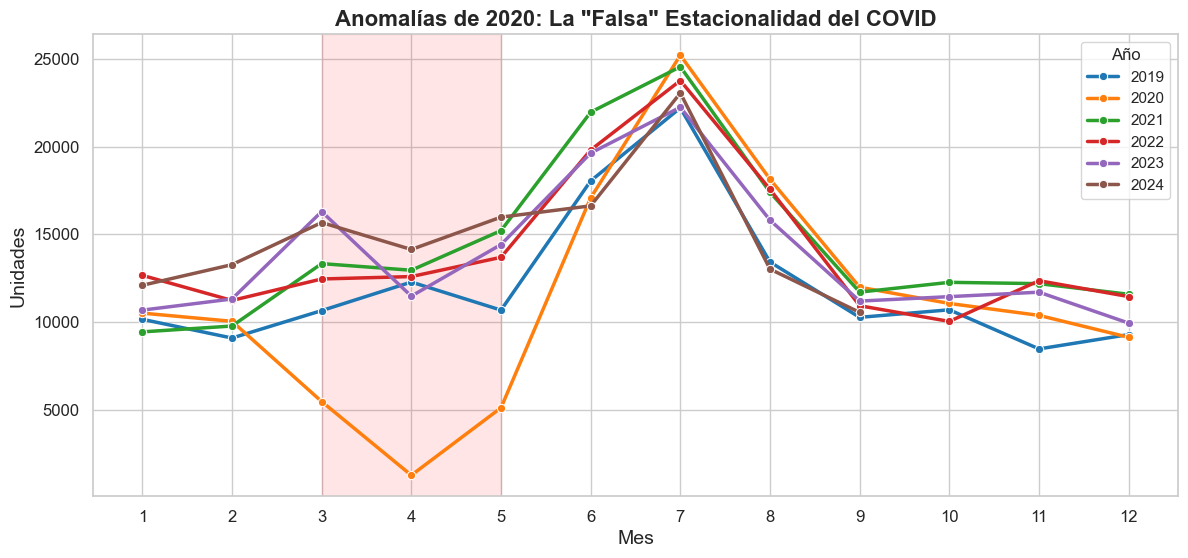

In [3]:
# 2. SECCION COVID
df_esp = df_m[(df_m['CodigoNacion'] == 108) & (df_m['Unidades'] > 0) & (df_m['Obsoleto'] == 'No')].copy()
df_trend = df_esp.groupby(['Año', 'Mes'])['Unidades'].sum().reset_index()
df_trend = df_trend[(df_trend['Año'] >= 2018) & (df_trend['Año'] <= 2024)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_trend, x='Mes', y='Unidades', hue='Año', palette='tab10', marker='o', linewidth=2.5)
plt.axvspan(3, 5, color='red', alpha=0.1)
plt.title('Anomalías de 2020: La "Falsa" Estacionalidad del COVID', fontsize=16, fontweight='bold')
plt.xticks(range(1, 13))
plt.show()


**💡 Conclusión sobre el filtrado de 2020:**

Como se puede observar en el gráfico anterior, el año 2020 presenta un comportamiento completamente **anómalo** respecto al resto de la serie temporal. La caída abrupta en la primera mitad del año y la recuperación irregular posterior hacen que estos datos sean **más dañinos que beneficiosos** para entrenar un modelo predictivo.

Al excluir 2020 del conjunto de entrenamiento:
- ✅ Preservamos la **estacionalidad real** del negocio.
- ✅ Evitamos que el modelo aprenda **patrones falsos** provocados por la pandemia.
- ✅ Mejoramos la **consistencia y fiabilidad** de las predicciones futuras.

Esta decisión se alinea con las mejores prácticas de la industria para el tratamiento de datos durante periodos de crisis global.


## 3. 🚗 ¿Por qué separamos el Canal "Fleet" (Flotas)?

En el análisis de datos de Cruzber, se identificó que el canal **Fleet** (ventas a flotas de vehículos) presenta un comportamiento de demanda fundamentalmente diferente al del canal B2B regular.

### 🎯 Características del Canal Fleet
- **Demanda Lumpy (irregular):** Las ventas a flotas se caracterizan por ser **intermitentes y de alto volumen**, con largos periodos sin actividad seguidos de pedidos muy grandes.
- **Sin estacionalidad clara:** A diferencia del canal B2B regular, que sigue patrones estacionales predecibles, las ventas a flotas dependen de **licitaciones, contratos y renovaciones** que no siguen un calendario fijo.
- **Alto impacto en agregados:** Si se mezclan ambos canales, los pedidos puntuales de flotas pueden distorsionar significativamente las métricas agregadas.

### 🔍 ¿Por qué no se puede modelar junto al B2B regular?
Un modelo que intente predecir simultáneamente demanda estacional (B2B regular) y demanda lumpy (Fleet) tendrá un rendimiento **subóptimo** en ambos casos, ya que los patrones subyacentes son contraddictorios.

### 📊 Evidencia comparativa
El siguiente gráfico compara el comportamiento semanal de ambos canales, mostrando claramente las diferencias en sus patrones de demanda:


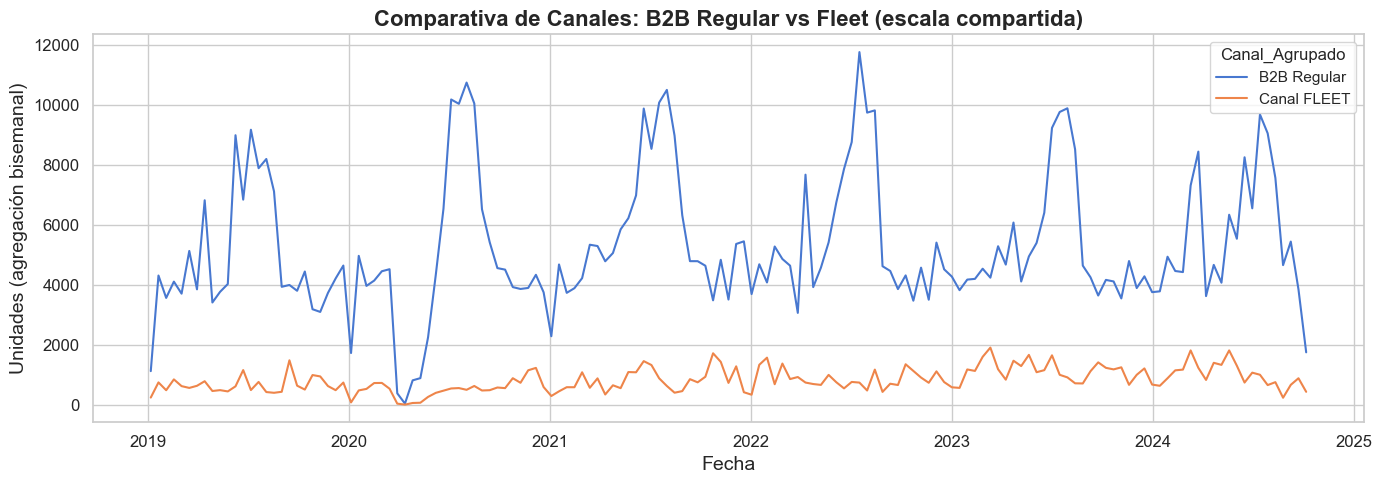

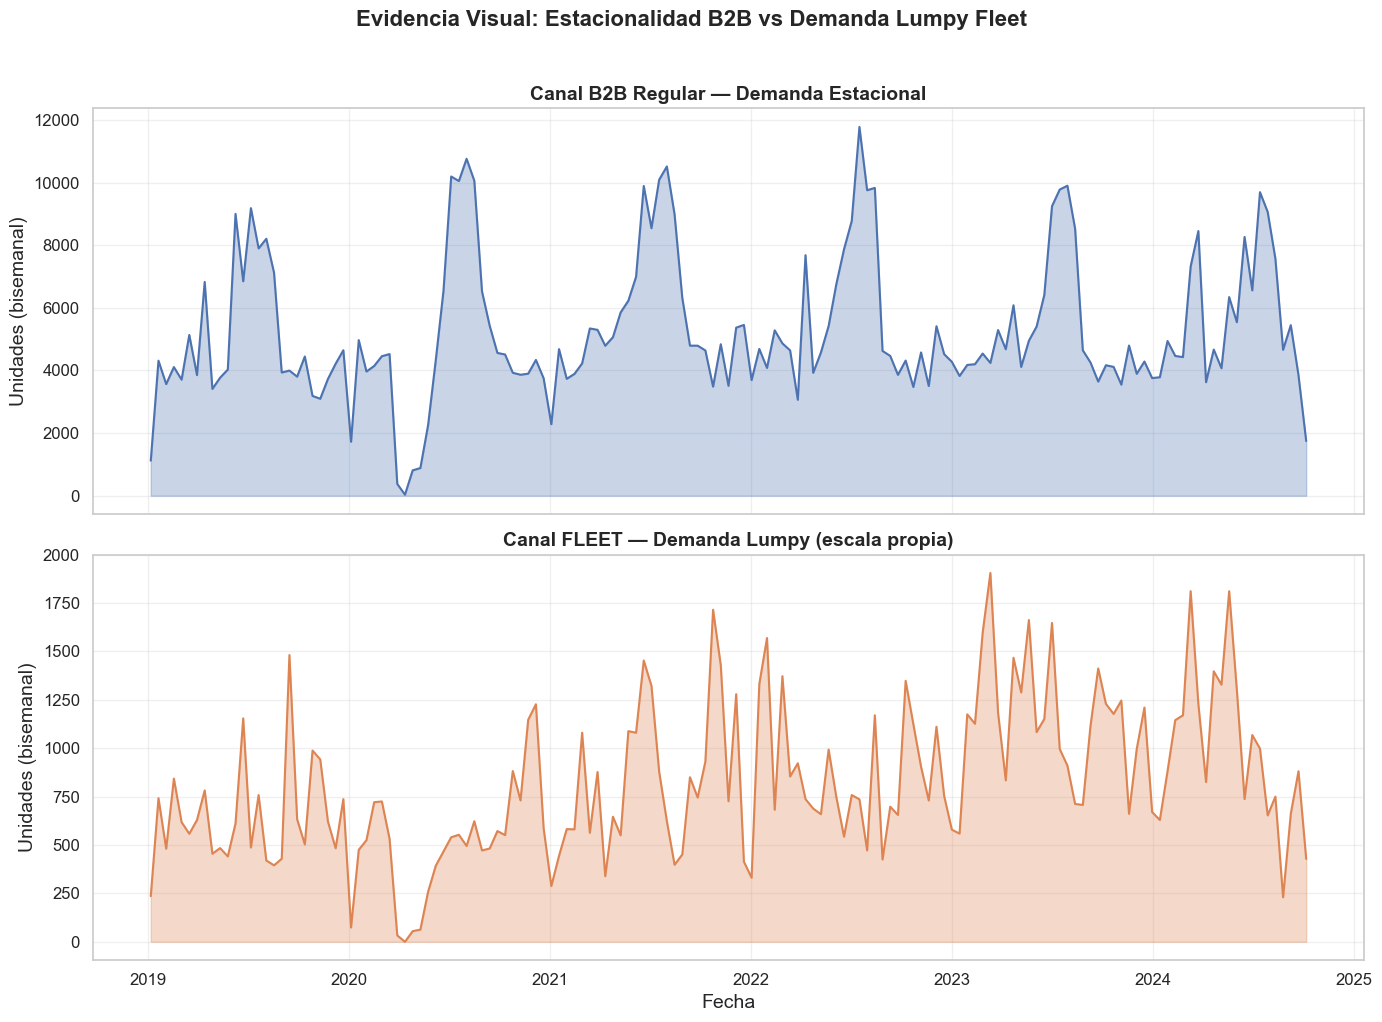


--- Estadísticas de demanda bisemanal por canal ---
                count         mean          std   min      max        cv
Canal_Agrupado                                                          
B2B Regular     151.0  5286.900662  2276.163942  34.0  11777.0  0.430529
Canal FLEET     151.0   820.966887   393.770973   0.0   1905.0  0.479643

Nota: Un CV (coef. de variación) alto indica mayor irregularidad en la demanda.


In [4]:
# 3. SECCION FLEET
df_esp['Canal_Agrupado'] = np.where(df_esp['TipoCruz'] == 'CruzFLEET', 'Canal FLEET', 'B2B Regular')
df_canal = df_esp.groupby(['Canal_Agrupado', 'FechaAlbaran'])['Unidades'].sum().reset_index()
df_canal.set_index('FechaAlbaran', inplace=True)
df_canal_weekly = df_canal.groupby('Canal_Agrupado').resample('2W')['Unidades'].sum().reset_index()

# --- Gráfico 1: Vista conjunta (escala compartida) ---
plt.figure(figsize=(14, 5))
sns.lineplot(data=df_canal_weekly, x='FechaAlbaran', y='Unidades', hue='Canal_Agrupado')
plt.title('Comparativa de Canales: B2B Regular vs Fleet (escala compartida)', fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Unidades (agregación bisemanal)')
plt.tight_layout()
plt.show()

# --- Gráfico 2: Fleet aislado con su propia escala ---
df_fleet = df_canal_weekly[df_canal_weekly['Canal_Agrupado'] == 'Canal FLEET'].copy()
df_b2b = df_canal_weekly[df_canal_weekly['Canal_Agrupado'] == 'B2B Regular'].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel superior: B2B Regular
axes[0].fill_between(df_b2b['FechaAlbaran'], df_b2b['Unidades'], alpha=0.3, color='#4C72B0')
axes[0].plot(df_b2b['FechaAlbaran'], df_b2b['Unidades'], color='#4C72B0', linewidth=1.5)
axes[0].set_title('Canal B2B Regular — Demanda Estacional', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Unidades (bisemanal)')
axes[0].grid(True, alpha=0.3)

# Panel inferior: Fleet con su propia escala
axes[1].fill_between(df_fleet['FechaAlbaran'], df_fleet['Unidades'], alpha=0.3, color='#DD8452')
axes[1].plot(df_fleet['FechaAlbaran'], df_fleet['Unidades'], color='#DD8452', linewidth=1.5)
axes[1].set_title('Canal FLEET — Demanda Lumpy (escala propia)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Unidades (bisemanal)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Evidencia Visual: Estacionalidad B2B vs Demanda Lumpy Fleet', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Estadísticas descriptivas para cuantificar la diferencia
print('\n--- Estadísticas de demanda bisemanal por canal ---')
stats = df_canal_weekly.groupby('Canal_Agrupado')['Unidades'].describe()
stats['cv'] = stats['std'] / stats['mean']  # Coeficiente de variación
print(stats[['count', 'mean', 'std', 'min', 'max', 'cv']].to_string())
print('\nNota: Un CV (coef. de variación) alto indica mayor irregularidad en la demanda.')


**💡 Conclusión sobre la separación del Canal Fleet:**

Las visualizaciones anteriores confirman de forma contundente la hipótesis:

- En el **primer gráfico** (escala compartida), la línea de Fleet queda prácticamente invisible frente al volumen de B2B Regular, lo que ya indica una diferencia de magnitud enorme.
- En el **segundo gráfico** (paneles con escala propia), se observa claramente que:
  - El canal **B2B Regular** presenta un patrón **estacional** reconocible y predecible.
  - El canal **Fleet** muestra una demanda **lumpy**: grandes picos esporádicos separados por periodos de muy baja actividad. No hay estacionalidad clara.
- Las **estadísticas descriptivas** lo cuantifican: el coeficiente de variación (CV) del canal Fleet es significativamente mayor, confirmando la alta irregularidad de su demanda.

Ventajas de separar ambos canales para el modelado:
- ✅ Permite diseñar **modelos especializados** para cada tipo de demanda.
- ✅ Mejora la **precisión predictiva** al eliminar ruido cruzado entre patrones.
- ✅ Facilita la **planificación de inventarios** con estrategias diferenciadas por canal.
- ✅ Abre la posibilidad de utilizar **técnicas específicas** para demanda intermitente (e.g., Croston, TSB) en el canal Fleet.


## 4. 🧹 Higiene del Dato: Filtrado de Unidades > 0 y Productos No Obsoletos

La calidad de los datos es **fundamental** para el éxito de cualquier modelo predictivo. En el proceso de preparación de datos para las iteraciones 21-23, se aplicaron dos filtros de higiene esenciales:

### 📋 Filtro 1: Unidades > 0
- Se eliminan las líneas con **unidades negativas o cero**, que corresponden a devoluciones, anulaciones o ajustes contables.
- Estas transacciones no representan **demanda real** del mercado, sino correcciones operativas.
- Incluirlas distorsionaría las métricas de demanda media y la detección de patrones estacionales.

### 📋 Filtro 2: Productos No Obsoletos
- Se excluyen productos marcados como **obsoletos** en el maestro de artículos.
- Los productos obsoletos tienen un ciclo de vida interrumpido, con demanda que cae artificialmente a cero.
- Incluir estos productos generaría **falsos positivos** de demanda cero e introduciría sesgos en el modelo.

### 📊 Distribución del estado de artículos y el impacto del filtrado
Los siguientes gráficos muestran la proporción de artículos por estado y el impacto cuantitativo de aplicar estos filtros:


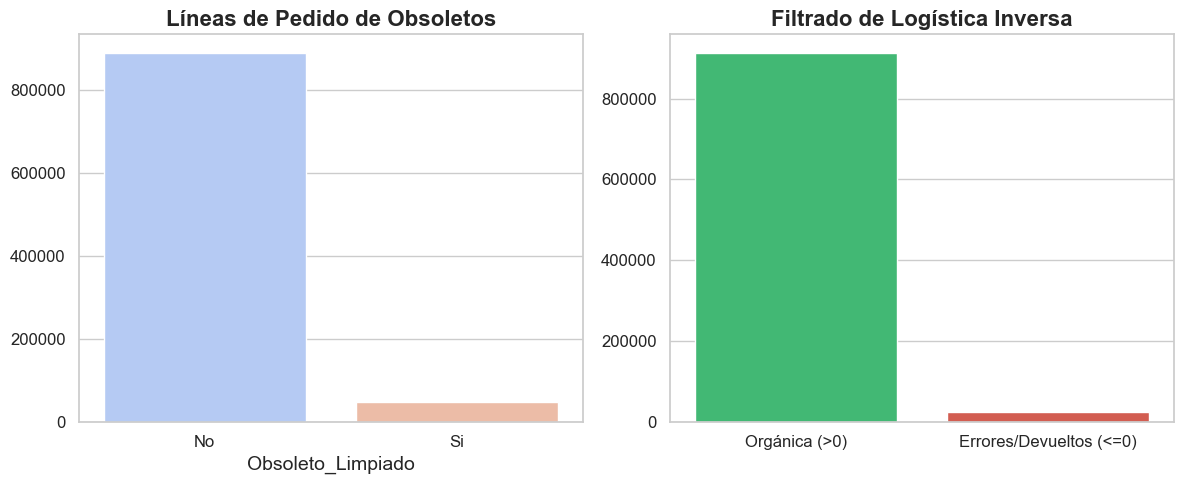

In [5]:
# 4. HIGIENE
df_m['Obsoleto_Limpiado'] = df_m['Obsoleto'].astype(str).str.strip().str.title()
articulos_estado = df_m['Obsoleto_Limpiado'].value_counts()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=articulos_estado.index, y=articulos_estado.values, palette='coolwarm')
plt.title('Líneas de Pedido de Obsoletos', fontweight='bold')

plt.subplot(1, 2, 2)
unidades_status = ['Orgánica (>0)', 'Errores/Devueltos (<=0)']
unidades_counts = [len(df_m[df_m['Unidades'] > 0]), len(df_m[df_m['Unidades'] <= 0])]
sns.barplot(x=unidades_status, y=unidades_counts, palette=['#2ECC71', '#E74C3C'])
plt.title('Filtrado de Logística Inversa', fontweight='bold')
plt.tight_layout()
plt.show()


**💡 Conclusión sobre la Higiene del Dato:**

La aplicación de estos filtros de higiene es una práctica estándar en la preparación de datos para modelos de predicción de demanda:

- ✅ Al filtrar **Unidades > 0**, nos aseguramos de trabajar exclusivamente con demanda genuina.
- ✅ Al excluir **productos obsoletos**, evitamos que artículos descontinuados contaminen los patrones de demanda activos.
- ✅ Estos filtros resultan en un dataset más **limpio, consistente y representativo** de la demanda real del mercado español.

La combinación de ambos filtros es la base sobre la que se construyen las features y se entrenan los modelos en las iteraciones 21, 22 y 23.


---

## 📌 Resumen de Decisiones de Negocio

A continuación se resumen las **cuatro decisiones estratégicas** tomadas para la preparación de datos de los modelos predictivos:

| # | Decisión | Justificación | Impacto |
|---|----------|---------------|---------|
| 1 | **Foco en España** | Concentra ~52% de la facturación en un solo país vs. +45 países con el 48% restante | Un solo modelo con reglas homogéneas (IVA, festivos, clima) controla la mitad de la facturación |
| 2 | **Exclusión de 2020** | Año COVID con demanda atípica que distorsiona patrones estacionales | Preserva la estacionalidad real y evita que el modelo aprenda señales falsas |
| 3 | **Separación Canal Fleet** | Demanda lumpy no estacional, incompatible con patrones B2B regulares | Permite modelos especializados y mayor precisión predictiva |
| 4 | **Higiene del Dato** | Filtrado de unidades ≤ 0 (devoluciones) y productos obsoletos | Dataset limpio y representativo de la demanda real activa |

Estas decisiones constituyen el **fundamento lógico y estratégico** sobre el que se construyen las iteraciones de modelado 21, 22 y 23 del proyecto de predicción de demanda de Cruzber.
